In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
from IPython.display import display, Markdown
import sportsdataverse.cfb as cfb

In [2]:
#data (same process as previous notebooks)
raw_pbp = cfb.load_cfb_pbp(seasons=[2021, 2022, 2023, 2024, 2025], return_as_pandas=True)

#FBS only
fbs_teams = ['ACC', 'Big 12', 'Big Ten', 'SEC', 'FBS Independents', 'American Athletic', 'Conference USA', 'Mid-American', 'Mountain West', 'Sun Belt', 'Pac-12']
schedule = cfb.load_cfb_schedule(seasons=[2021,2022, 2023, 2024, 2025], return_as_pandas=True)

home_conferences = schedule[
    ['game_id', 'season', 'home_id', 'home_conference']
].rename(columns={'home_id': 'pos_team_id', 'home_conference': 'conference'})
away_conferences = schedule[
    ['game_id', 'season', 'away_id', 'away_conference']
].rename(columns={'away_id': 'pos_team_id', 'away_conference': 'conference'})
conference_lookup = pd.concat([home_conferences, away_conferences], ignore_index=True)

fbs_pbp_all = raw_pbp.merge(
    conference_lookup,
    on=['game_id', 'season', 'pos_team_id'],
    how='left',
    validate='many_to_one'
)
fbs_pbp_all = fbs_pbp_all[fbs_pbp_all['conference'].isin(fbs_teams)].copy()

fbs_pbp = raw_pbp.merge(
    conference_lookup,
    on=['game_id', 'season', 'pos_team_id'],
    how='left',
    validate='many_to_one' #prevents duplicate rows
)
fbs_pbp = fbs_pbp[fbs_pbp['conference'].isin(fbs_teams)].copy()

In [3]:
#Home/Away Only (merge schedule data to get game locations)

# Add game location from the schedule data
fbs_pbp_ha = fbs_pbp.drop(columns=['neutral_site'], errors='ignore').merge(
    schedule[['game_id', 'season', 'neutral_site']].drop_duplicates(),
    on=['game_id', 'season'],
    how='left',
    validate='many_to_one'
)

#filter out neutral site games
fbs_pbp_ha = fbs_pbp_ha[fbs_pbp_ha['neutral_site'] == False].copy()

In [ ]:
# SRS by season based on the running score differential
# pos_score_diff is from the possession team's perspective.

fbs_team_seasons = set(zip(
    schedule.loc[schedule['home_conference'].isin(fbs_teams), 'season'],
    schedule.loc[schedule['home_conference'].isin(fbs_teams), 'home_id']
))
fbs_team_seasons.update(zip(
    schedule.loc[schedule['away_conference'].isin(fbs_teams), 'season'],
    schedule.loc[schedule['away_conference'].isin(fbs_teams), 'away_id']
))

play_results = fbs_pbp_ha[[
    'game_id', 'season', 'pos_team_id', 'def_pos_team_id', 'pos_score_diff'
]].dropna().rename(columns={
    'pos_team_id': 'team_id',
    'def_pos_team_id': 'opponent_id',
    'pos_score_diff': 'score_diff'
})

home_lookup = schedule[[
    'game_id', 'season', 'home_id'
]].drop_duplicates('game_id')
play_results = play_results.merge(
    home_lookup,
    on=['game_id', 'season'],
    how='left',
    validate='many_to_one'
)

#create home col
play_results['home_indicator'] = (
    play_results['team_id'] == play_results['home_id']
).astype(float)

# Ensure only FBS teams are included.
team_keys = list(zip(play_results['season'], play_results['team_id']))
opponent_keys = list(zip(play_results['season'], play_results['opponent_id']))
play_results = play_results[
    pd.Series(team_keys, index=play_results.index).isin(fbs_team_seasons)
    & pd.Series(opponent_keys, index=play_results.index).isin(fbs_team_seasons)
].copy()

# Estimate team strength and separate home-field effect together
def calc_srs(season_df):
    #matrices one-hot encode team/opp
    team_matrix = pd.get_dummies(
        season_df['team_id'].astype(str),
        dtype=float
    )
    opponent_matrix = pd.get_dummies(
        season_df['opponent_id'].astype(str),
        dtype=float
    ).reindex(columns=team_matrix.columns, fill_value=0)

    X = np.column_stack([
        (team_matrix - opponent_matrix).to_numpy(),
        season_df['home_indicator'].to_numpy()
    ])
    coefficients = np.linalg.lstsq(
        X,
        season_df['score_diff'].to_numpy(),
        rcond=None
    )[0]

    ratings = pd.DataFrame({
        'team_id': team_matrix.columns,
        'srs': coefficients[:-1]
    })
    ratings['home_advantage'] = coefficients[-1]
    return ratings

#breaks down by year
srs_by_season = pd.concat([
    calc_srs(season_df).assign(season=yr)
    for yr, season_df in play_results.groupby('season')
], ignore_index=True)

team_name_lookup = pd.concat([
    schedule[['home_id', 'home_team']].rename(
        columns={'home_id': 'team_id', 'home_team': 'team_name'}
    ),
    schedule[['away_id', 'away_team']].rename(
        columns={'away_id': 'team_id', 'away_team': 'team_name'}
    )
]).drop_duplicates('team_id')
team_name_lookup['team_id'] = team_name_lookup['team_id'].astype(str)

#finds team names for each team_id
srs_by_season = srs_by_season.merge(
    team_name_lookup,
    on='team_id',
    how='left'
)

#top/bottom 10 teams by season
for yr in sorted(srs_by_season['season'].unique()):
    season_ratings = srs_by_season[
        srs_by_season['season'] == yr
    ].sort_values('srs', ascending=False).reset_index(drop=True)
    season_ratings['rank'] = season_ratings.index + 1

    # display(Markdown(f'### SRS: {yr}'))
    # display(season_ratings.head(10)[['rank', 'team_name', 'srs']])
    # display(Markdown('**Worst teams**'))
    # display(season_ratings.tail(10).sort_values('srs')[['rank', 'team_name', 'srs']])


In [ ]:
# FBS Game Control: simple and opponent-adjusted (based on Schuckers' model from class notebook)

schedule_info = schedule[[
    'game_id', 'season', 'home_id', 'away_id', 'home_team', 'away_team',
    'home_conference', 'away_conference', 'neutral_site'
]].drop_duplicates('game_id')
schedule_info = schedule_info[
    schedule_info['home_conference'].isin(fbs_teams)
    & schedule_info['away_conference'].isin(fbs_teams)
].copy()

gc_pbp = fbs_pbp_ha.merge(
    schedule_info,
    on=['game_id', 'season'],
    how='left',
    validate='many_to_one',
    suffixes=('', '_schedule')
).copy()

gc_pbp['period_number'] = pd.to_numeric(gc_pbp['period'], errors='coerce')
gc_pbp['clock_seconds'] = (
    pd.to_numeric(gc_pbp['clock.minutes'], errors='coerce').fillna(0) * 60
    + pd.to_numeric(gc_pbp['clock.seconds'], errors='coerce').fillna(0)
)
gc_pbp = gc_pbp.sort_values(
    ['season', 'game_id', 'period_number', 'clock_seconds'],
    ascending=[True, True, True, False]
).copy()

gc_pbp['home_lead'] = gc_pbp['homeScore'] - gc_pbp['awayScore']
prev_clock = gc_pbp.groupby(
    ['game_id', 'period_number']
)['clock_seconds'].shift(1).fillna(1800)
gc_pbp['play_duration'] = (prev_clock - gc_pbp['clock_seconds']).clip(lower=0)

def calc_game_gc(group):
    total_time = group['play_duration'].sum()
    denominator = total_time if total_time > 0 else 1.0
    home_gc = (group['home_lead'] * group['play_duration']).sum() / denominator
    return pd.Series({
        'total_time': total_time,
        'home_gc': home_gc,
        'away_gc': -home_gc
    })

game_control_by_game = (
    gc_pbp.groupby(
        ['season', 'game_id', 'home_id', 'away_id', 'home_team', 'away_team'],
        group_keys=False
    )
    .apply(calc_game_gc)
    .reset_index()
)

def calc_adj_gc(df):
    home_matrix = pd.get_dummies(df['home_id'].astype(str), dtype=float)
    away_matrix = pd.get_dummies(df['away_id'].astype(str), dtype=float)
    away_matrix = away_matrix.reindex(columns=home_matrix.columns, fill_value=0)
    X = home_matrix - away_matrix
    X['home_advantage'] = 1.0     #home team effect 

    fit = sm.OLS(df['home_gc'].to_numpy(), X).fit()
    ratings = pd.DataFrame({
        'team_id': home_matrix.columns,
        'Adj_GC': fit.params[home_matrix.columns].to_numpy()
    })
    ratings['Adj_GC'] = ratings['Adj_GC'] - ratings['Adj_GC'].mean()
    ratings['home_advantage'] = fit.params['home_advantage'] #finds coefficient for home advantage
    return ratings

ratings_by_season = pd.concat([
    calc_adj_gc(season_df).assign(season=yr)
    for yr, season_df in game_control_by_game.groupby('season')
], ignore_index=True)

team_name_lookup = pd.concat([
    schedule_info[['home_id', 'home_team']].rename(
        columns={'home_id': 'team_id', 'home_team': 'team_name'}
    ),
    schedule_info[['away_id', 'away_team']].rename(
        columns={'away_id': 'team_id', 'away_team': 'team_name'}
    )
]).drop_duplicates('team_id')
team_name_lookup['team_id'] = team_name_lookup['team_id'].astype(str)
ratings_by_season = ratings_by_season.merge(
    team_name_lookup,
    on='team_id',
    how='left'
)
ratings_by_season.sort_values(
    ['season', 'Adj_GC'],
    ascending=[True, False]
).tail(10)

#interpreting: 
#Adj_GC is the estimated average lead in points for that team in that season
#home_advantage is the estimated point boost for an average home team in that season

,team_id,Adj_GC,home_advantage,season,team_name
640,5,-9.663680,1.687526,2025,UAB
587,2433,-9.914839,1.687526,2025,UL Monroe
628,324,-10.195551,1.687526,2025,Coastal Carolina
575,2309,-10.254411,1.687526,2025,Kent State
611,2638,-10.277291,1.687526,2025,UTEP
551,2006,-10.817140,1.687526,2025,Akron
584,242,-10.878933,1.687526,2025,Rice
557,2050,-12.059091,1.687526,2025,Ball State
586,2429,-12.984111,1.687526,2025,Charlotte
526,113,-16.884315,1.687526,2025,Massachusetts


In [42]:
# Report best and worst opponent-adjusted Game Control teams by season

# for yr in sorted(ratings_by_season['season'].unique()):
#     adjusted_ratings = ratings_by_season[
#         ratings_by_season['season'] == yr
#     ].sort_values('Adj_GC', ascending=False).reset_index(drop=True)
#     adjusted_ratings['rank'] = adjusted_ratings.index + 1

#     display(Markdown(f'### Opponent-Adjusted Game Control: {yr}'))
#     display(adjusted_ratings.head(10)[[
#         'rank', 'team_name', 'Adj_GC'
#     ]])
#     display(Markdown('**Worst teams**'))
#     display(adjusted_ratings.tail(10).sort_values('Adj_GC')[[
#         'rank', 'team_name', 'Adj_GC'
#     ]])

In [ ]:
# Opponent-adjusted Average Win Probability
# Use the home team's pre-play win probability and time weight it within each game.

wp_pbp = fbs_pbp_ha.merge(
    schedule_info,
    on=['game_id', 'season'],
    how='left',
    validate='many_to_one',
    suffixes=('', '_schedule')
).copy()

wp_pbp['period_number'] = pd.to_numeric(wp_pbp['period'], errors='coerce')
wp_pbp['clock_seconds'] = (
    pd.to_numeric(wp_pbp['clock.minutes'], errors='coerce').fillna(0) * 60
    + pd.to_numeric(wp_pbp['clock.seconds'], errors='coerce').fillna(0)
)
wp_pbp = wp_pbp.sort_values(
    ['season', 'game_id', 'period_number', 'clock_seconds'],
    ascending=[True, True, True, False]
).copy()

prev_clock = wp_pbp.groupby(
    ['game_id', 'period_number']
)['clock_seconds'].shift(1).fillna(1800)
wp_pbp['play_duration'] = (prev_clock - wp_pbp['clock_seconds']).clip(lower=0)
wp_pbp = wp_pbp.dropna(subset=['home_wp_before']).copy()

def calc_game_wp(group):
    total_time = group['play_duration'].sum()
    denominator = total_time if total_time > 0 else 1.0
    home_wp = (
        group['home_wp_before'] * group['play_duration']
    ).sum() / denominator
    home_wp = home_wp - 0.5
    return pd.Series({
        'total_time': total_time,
        'home_wp': home_wp,
        'away_wp': -home_wp
    })

game_win_prob_by_game = (
    wp_pbp.groupby(
        ['season', 'game_id', 'home_id', 'away_id', 'home_team', 'away_team'],
        group_keys=False
    )
    .apply(calc_game_wp)
    .reset_index()
)

def calc_adj_wp(df):
    home_matrix = pd.get_dummies(df['home_id'].astype(str), dtype=float)
    away_matrix = pd.get_dummies(df['away_id'].astype(str), dtype=float)
    away_matrix = away_matrix.reindex(columns=home_matrix.columns, fill_value=0)
    X = home_matrix - away_matrix
    X['home_advantage'] = 1.0     #same home team effect

    fit = sm.OLS(df['home_wp'].to_numpy(), X).fit()
    ratings = pd.DataFrame({
        'team_id': home_matrix.columns,
        'Adj_WP': fit.params[home_matrix.columns].to_numpy()
    })
    ratings['Adj_WP'] = ratings['Adj_WP'] - ratings['Adj_WP'].mean()
    ratings['home_advantage'] = fit.params['home_advantage'] #finds coefficient for home advantage
    return ratings

win_prob_ratings_by_season = pd.concat([
    calc_adj_wp(season_df).assign(season=yr)
    for yr, season_df in game_win_prob_by_game.groupby('season')
], ignore_index=True)

team_name_lookup = pd.concat([
    schedule_info[['home_id', 'home_team']].rename(
        columns={'home_id': 'team_id', 'home_team': 'team_name'}
    ),
    schedule_info[['away_id', 'away_team']].rename(
        columns={'away_id': 'team_id', 'away_team': 'team_name'}
    )
]).drop_duplicates('team_id')
team_name_lookup['team_id'] = team_name_lookup['team_id'].astype(str)
win_prob_ratings_by_season = win_prob_ratings_by_season.merge(
    team_name_lookup,
    on='team_id',
    how='left'
)

win_prob_ratings_by_season.sort_values(
    ['season', 'Adj_WP'],
    ascending=[True, False]
).head(10)

#interpreting:
#Adj_WP is the estimated average lead in win probability for that team in that season
#home_advantage is the estimated win probability boost for an average home team in that season

,team_id,Adj_WP,home_advantage,season,team_name
117,61,0.485229,0.052534,2021,Georgia
21,194,0.446167,0.052534,2021,Ohio State
104,333,0.445862,0.052534,2021,Alabama
5,130,0.398468,0.052534,2021,Michigan
38,2132,0.357849,0.052534,2021,Cincinnati
92,275,0.345947,0.052534,2021,Wisconsin
27,201,0.333435,0.052534,2021,Oklahoma
41,221,0.320343,0.052534,2021,Pittsburgh
74,254,0.316315,0.052534,2021,Utah
68,2483,0.290192,0.052534,2021,Oregon


In [46]:
# Report best and worst opponent-adjusted Average Win Probability teams by season

# for yr in sorted(win_prob_ratings_by_season['season'].unique()):
#     season_ratings = win_prob_ratings_by_season[
#         win_prob_ratings_by_season['season'] == yr
#     ].sort_values('Adj_WP', ascending=False).reset_index(drop=True)
#     season_ratings['rank'] = season_ratings.index + 1

#     display(Markdown(f'### Opponent-Adjusted Average Win Probability: {yr}'))
#     display(season_ratings.head(10)[[
#         'rank', 'team_name', 'Adj_WP'
#     ]])
#     display(Markdown('**Worst teams**'))
#     display(season_ratings.tail(10).sort_values('Adj_WP')[[
#         'rank', 'team_name', 'Adj_WP'
#     ]])

In [ ]:
# Predictive comparison of SRS, Game Control, and Win Probability
# Random game-level 85/15 evaluation; ratings are refit using training games only.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss
from sklearn.model_selection import train_test_split

score_columns = [
    ('home_points', 'away_points'),
    ('home_score', 'away_score'),
    ('homeScore', 'awayScore')
]
for home_score_col, away_score_col in score_columns:
    if home_score_col in schedule.columns and away_score_col in schedule.columns:
        break

games = schedule_info[[
    'game_id', 'season', 'home_id', 'away_id', 'neutral_site'
]].drop_duplicates('game_id').merge(
    schedule[['game_id', home_score_col, away_score_col]].drop_duplicates('game_id'),
    on='game_id',
    how='inner',
    validate='one_to_one'
)
games[home_score_col] = pd.to_numeric(games[home_score_col], errors='coerce')
games[away_score_col] = pd.to_numeric(games[away_score_col], errors='coerce')
games = games.dropna(subset=[home_score_col, away_score_col]).copy()
games['neutral_site'] = games['neutral_site'].fillna(False)
games = games[~games['neutral_site']].copy()
games['home_id'] = games['home_id'].astype(str)
games['away_id'] = games['away_id'].astype(str)
games['home_win'] = (games[home_score_col] > games[away_score_col]).astype(int)

def fit_training_ratings(metric, training_games):
    training_ids = set(training_games['game_id'])
    if metric == 'SRS':
        training_plays = play_results[play_results['game_id'].isin(training_ids)]
        return pd.concat([
            calc_srs(season_df).assign(season=yr)
            for yr, season_df in training_plays.groupby('season')
        ], ignore_index=True).rename(columns={'srs': 'rating'})

    source = game_control_by_game if metric == 'Game Control' else game_win_prob_by_game
    source = source[source['game_id'].isin(training_ids)]
    rating_function = calc_adj_gc if metric == 'Game Control' else calc_adj_wp
    rating_column = 'Adj_GC' if metric == 'Game Control' else 'Adj_WP'
    return pd.concat([
        rating_function(season_df).assign(season=yr)
        for yr, season_df in source.groupby('season')
    ], ignore_index=True).rename(columns={rating_column: 'rating'})

def add_rating_difference(frame, ratings):
    home_ratings = ratings.rename(columns={
        'team_id': 'home_id',
        'rating': 'home_rating',
        'home_advantage': 'home_field_effect'
    })[['season', 'home_id', 'home_rating', 'home_field_effect']]
    away_ratings = ratings.rename(columns={
        'team_id': 'away_id', 'rating': 'away_rating'
    })[['season', 'away_id', 'away_rating']]
    result = frame.merge(
        home_ratings, on=['season', 'home_id'], how='left'
    ).merge(
        away_ratings, on=['season', 'away_id'], how='left'
    )
    result['rating_difference'] = (
        result['home_rating'].fillna(0)
        - result['away_rating'].fillna(0)
        + result['home_field_effect'].fillna(0)     #home effect added
    )
    return result

metrics = ['SRS', 'Game Control', 'Win Probability']
results = []
seed_values = range(10)

# Random train/test splits for a 15% test set, stratified by home win/loss.
for seed in seed_values:
    train_games, test_games = train_test_split(
        games,
        test_size=0.15,
        random_state=seed,
        stratify=games['home_win']
    )
    for metric in metrics:
        ratings = fit_training_ratings(metric, train_games)
        train_features = add_rating_difference(train_games, ratings)
        test_features = add_rating_difference(test_games, ratings)

        classifier = LogisticRegression(solver='lbfgs', max_iter=1000)
        classifier.fit(
            train_features[['rating_difference']],
            train_features['home_win']
        )
        probabilities = classifier.predict_proba(
            test_features[['rating_difference']]
        )[:, 1]
        predictions = (probabilities >= 0.5).astype(int)
        results.append({
            'seed': seed,
            'metric': metric,
            'log_loss': log_loss(test_features['home_win'], probabilities),
            'brier_score': brier_score_loss(test_features['home_win'], probabilities),
            'roc_auc': roc_auc_score(test_features['home_win'], probabilities),
            'accuracy': accuracy_score(test_features['home_win'], predictions)
        })

prediction_results = pd.DataFrame(results)
summary = (
    prediction_results.groupby('metric')
    [['log_loss', 'brier_score', 'roc_auc', 'accuracy']]
    .agg(['mean', 'std'])
    .sort_values(('log_loss', 'mean'))
)
summary


log_loss           brier_score             roc_auc            \
                     mean       std        mean       std      mean       std   
metric                                                                          
Win Probability  0.505934  0.021523    0.169549  0.008990  0.822503  0.017531   
SRS              0.554790  0.020482    0.185426  0.008154  0.795992  0.015238   
Game Control     0.556931  0.018423    0.186858  0.007604  0.791369  0.014461   

                 accuracy            
                     mean       std  
metric                               
Win Probability  0.746140  0.022819  
SRS              0.724449  0.017747  
Game Control     0.716728  0.016679

Win Probability performed the best of the three, with SRS and Game Control following closely behind. AWP had the best value in every category (lower log_loss and brier_score are better), while the other two are very similar in their means and only slightly less parallel in their standard deviations--which are more descriptive than independent, as there can be some correlation when games involving the same teams are part of the test set. I decided on an 85-15 split just due to the small amount of games in a season that can be trained/tested on, and I decided to randomly select games from throughout the year instead of choosing the last 1, 2, 3, etc. weeks of the year. This is because of the fact that the point of the season in which a game is played is important and hardly independent. A home opener against a Group of 6 opponent is a lot different than a conference championship against a top-10 team. I chose to include playoffs as well, both to increase the number of games available to train/test on, but also because postseason games are a great measure to how good your team is, especially if you dominate a game against a playoff team.

In [14]:
# Non-overlapping repeatability of the three metrics
# Ratings are calculated separately on 60% and 40% of the games.
repeatability_results = []

for seed in seed_values:
    sample_60, sample_40 = train_test_split(
        games,
        test_size=0.40,
        random_state=seed,
        stratify=games['home_win']
    )
    for metric in metrics:
        ratings_60 = fit_training_ratings(metric, sample_60)
        ratings_40 = fit_training_ratings(metric, sample_40)
        ratings_60['team_id'] = ratings_60['team_id'].astype(str)
        ratings_40['team_id'] = ratings_40['team_id'].astype(str)
        comparison = ratings_60.merge(
            ratings_40,
            on=['season', 'team_id'],
            how='inner',
            suffixes=('_60', '_40')
        )

        season_results = []
        for season, season_df in comparison.groupby('season'):
            if len(season_df) < 3:
                continue
            ratings_60_rank = season_df['rating_60'].rank(
                ascending=False, method='min'
            )
            ratings_40_rank = season_df['rating_40'].rank(
                ascending=False, method='min'
            )
            top_15_60 = set(
                season_df.loc[ratings_60_rank <= 15, 'team_id']
            )
            top_15_40 = set(
                season_df.loc[ratings_40_rank <= 15, 'team_id']
            )
            top_15_overlap = (
                len(top_15_60 & top_15_40)
                / len(top_15_40)
                if top_15_40 else np.nan
            )
            season_results.append({
                'pearson_correlation': season_df[
                    'rating_60'
                ].corr(season_df['rating_40'], method='pearson'),
                'spearman_correlation': season_df[
                    'rating_60'
                ].corr(season_df['rating_40'], method='spearman'),
                'top_15_overlap': top_15_overlap,
                'team_coverage': len(season_df)
            })

        seed_summary = pd.DataFrame(season_results).mean(numeric_only=True)
        repeatability_results.append({
            'seed': seed,
            'metric': metric,
            'pearson_correlation': seed_summary['pearson_correlation'],
            'spearman_correlation': seed_summary['spearman_correlation'],
            'top_15_overlap': seed_summary['top_15_overlap'],
            'team_coverage': seed_summary['team_coverage']
        })

repeatability_results = pd.DataFrame(repeatability_results)
repeatability_summary = (
    repeatability_results.groupby('metric')
    [[
        'pearson_correlation', 'spearman_correlation',
        'top_15_overlap', 'team_coverage'
    ]]
    .agg(['mean', 'std'])
    .sort_values(('spearman_correlation', 'mean'), ascending=False)
)
repeatability_summary


pearson_correlation           spearman_correlation            \
                               mean       std                 mean       std   
metric                                                                         
Win Probability            0.818253  0.017009             0.811378  0.019956   
SRS                        0.656991  0.014692             0.655461  0.017682   
Game Control               0.642792  0.019543             0.638439  0.018243   

                top_15_overlap           team_coverage            
                          mean       std          mean       std  
metric                                                            
Win Probability       0.616000  0.051371        121.10  1.449138  
SRS                   0.421333  0.035666        132.06  0.353396  
Game Control          0.453333  0.032049        121.10  1.449138

I originally started with the same 85-15 split, comparing the 85% set to the full dataset, before I realized that a non-overlapping comparison would be more useful. The 60% and 40% ratings are calculated from completely separate games. Win Probability again outperforms the other two metrics, this time more significantly leading SRS and Game Control, which are mostly parallel in repeatability measures as well. 

In [ ]:
#VIZ Section

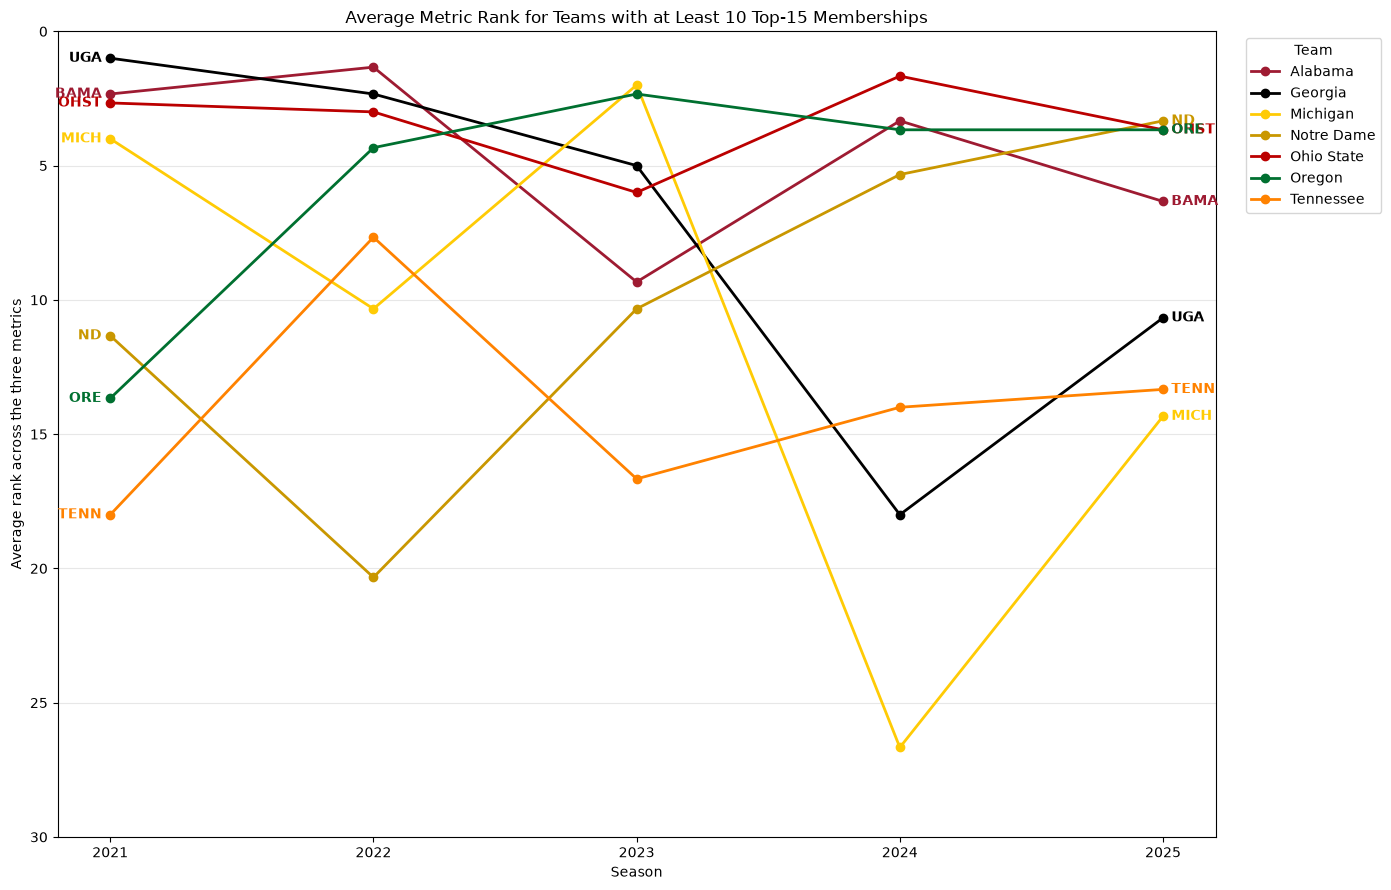

In [42]:
# Teams ranked in the top 15 in at least 10 metric-season combinations

metric_tables = pd.concat([
    srs_by_season[['season', 'team_id', 'team_name', 'srs']].rename(
        columns={'srs': 'value'}
    ).assign(metric='SRS'),
    ratings_by_season[['season', 'team_id', 'team_name', 'Adj_GC']].rename(
        columns={'Adj_GC': 'value'}
    ).assign(metric='Adjusted Game Control'),
    win_prob_ratings_by_season[['season', 'team_id', 'team_name', 'Adj_WP']].rename(
        columns={'Adj_WP': 'value'}
    ).assign(metric='Adjusted Win Probability')
], ignore_index=True)

metric_tables['rank'] = metric_tables.groupby(
    ['season', 'metric']
)['value'].rank(method='min', ascending=False)

top_15_by_metric = metric_tables[metric_tables['rank'] <= 15].copy()

repeatable_teams = (
    top_15_by_metric.groupby(['team_id', 'team_name'])
    .size()
    .reset_index(name='top_15_memberships')
)
repeatable_teams = repeatable_teams[
    repeatable_teams['top_15_memberships'] >= 10
].copy()

average_rank_by_season = (
    metric_tables[
        metric_tables['team_id'].isin(repeatable_teams['team_id'])
        & metric_tables['season'].between(2021, 2025)
    ]
    .groupby(['season', 'team_id', 'team_name'], as_index=False)
    .agg(
        average_rank=('rank', 'mean'),
        metrics_ranked=('rank', 'count')
    )
)

plot_data = average_rank_by_season.merge(
    repeatable_teams[['team_id', 'top_15_memberships']],
    on='team_id',
    how='left'
)

colors = {
    'Georgia': '#000000',
    'Alabama': '#9E1B32',
    'Ohio State': '#BB0000',
    'Michigan': '#FFCB05',
    'Notre Dame': '#C99700',
    'Oregon': '#007030',
    'Tennessee': '#FF8200'
}
abbreviations = {
    'Georgia': 'UGA',
    'Alabama': 'BAMA',
    'Ohio State': 'OHST',
    'Michigan': 'MICH',
    'Notre Dame': 'ND',
    'Oregon': 'ORE',
    'Tennessee': 'TENN'
}

fig, ax = plt.subplots(figsize=(14, 9))
for team_name, team_data in plot_data.groupby('team_name'):
    team_data = team_data.sort_values('season').reset_index(drop=True)
    team_color = colors.get(team_name, '#777777')
    ax.plot(
        team_data['season'],
        team_data['average_rank'],
        marker='o',
        linewidth=2,
        color=team_color,
        label=team_name
    )

    endpoints = [team_data.iloc[0]]
    if len(team_data) > 1:
        endpoints.append(team_data.iloc[-1])
    for endpoint_index, endpoint in enumerate(endpoints):
        is_start = endpoint_index == 0
        ax.annotate(
            abbreviations.get(team_name, team_name[:4].upper()),
            xy=(endpoint['season'], endpoint['average_rank']),
            xytext=(-6 if is_start else 6, 0),
            textcoords='offset points',
            ha='right' if is_start else 'left',
            va='center',
            color=team_color,
            fontweight='bold',
            clip_on=False
        )

ax.invert_yaxis()
ax.set_ylim(30, 0)
ax.set_xticks(range(2021, 2026))
ax.set_xlabel('Season')
ax.set_ylabel('Average rank across the three metrics')
ax.set_title('Average Metric Rank for Teams with at Least 10 Top-15 Memberships')
ax.grid(axis='y', alpha=0.3)
ax.legend(
    title='Team',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
fig.tight_layout()
plt.show()

#plot_data.sort_values(['season', 'average_rank']).head(20)


FUN FACT: Charlotte was in the bottom 10 in 6 of the 15 lists!
Top 15 in each metric EVERY year: Alabama, Ohio State
Bottom 30+ in each metric EVERY year: Akron, Eastern Michigan, UMass, UL Monroe

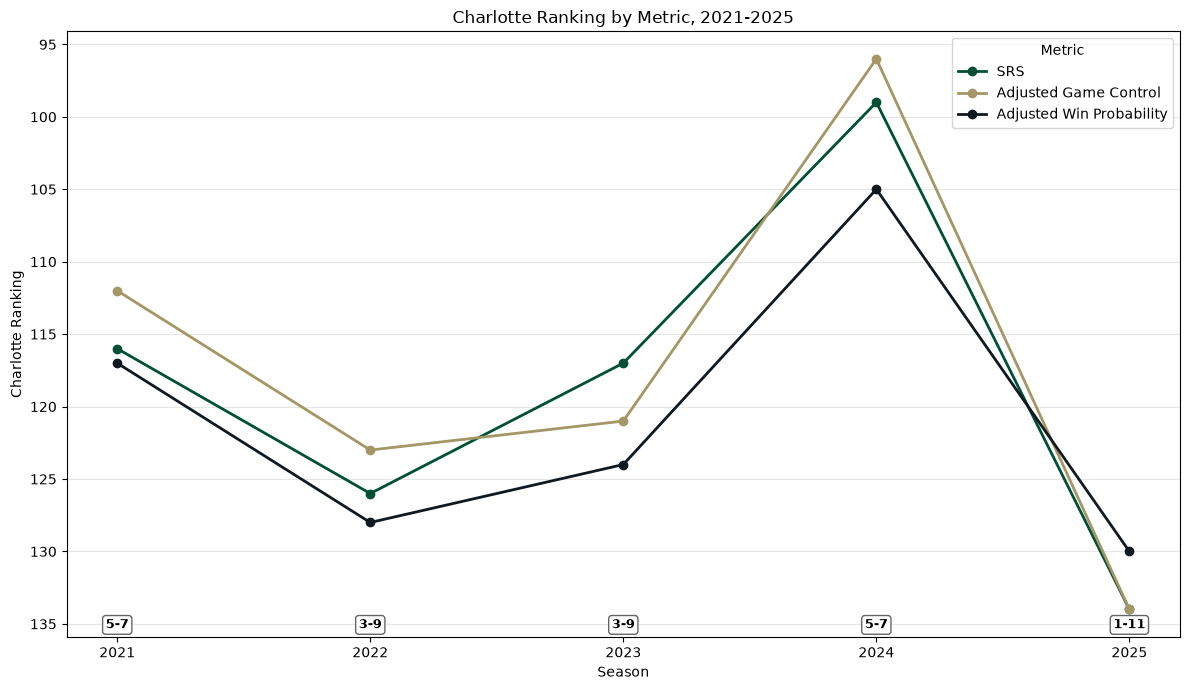

In [43]:
# Charlotte viz
charlotte_ranks = metric_tables[
    (metric_tables['team_name'] == 'Charlotte')
    & metric_tables['season'].between(2021, 2025)
][['season', 'metric', 'rank']].copy()

metric_order = [
    'SRS',
    'Adjusted Game Control',
    'Adjusted Win Probability'
]
charlotte_ranks['metric'] = pd.Categorical(
    charlotte_ranks['metric'],
    categories=metric_order,
    ordered=True
)
charlotte_ranks = charlotte_ranks.sort_values(['metric', 'season'])

charlotte_colors = {
    'SRS': '#005035',
    'Adjusted Game Control': '#A49665',
    'Adjusted Win Probability': '#101820'
}
winloss = ['5-7', '3-9', '3-9', '5-7', '1-11']

fig, ax = plt.subplots(figsize=(12, 7))
for metric_name, metric_data in charlotte_ranks.groupby('metric', observed=True):
    ax.plot(
        metric_data['season'],
        metric_data['rank'],
        marker='o',
        linewidth=2,
        color=charlotte_colors[metric_name],
        label=metric_name
    )

ax.invert_yaxis()
ax.set_xticks(range(2021, 2026))
ax.set_xlabel('Season')
ax.set_ylabel('Charlotte Ranking')
ax.set_title('Charlotte Ranking by Metric, 2021-2025')
ax.grid(axis='y', alpha=0.3)

for season, record in zip(range(2021, 2026), winloss):
    ax.text(
        season,
        135.5,
        record,
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        clip_on=False,
        bbox={
            'boxstyle': 'round,pad=0.25',
            'facecolor': 'white',
            'edgecolor': '#666666'
        }
    )

ax.legend(title='Metric')
fig.tight_layout()
plt.show()

#charlotte_ranks.sort_values(['season', 'metric'])


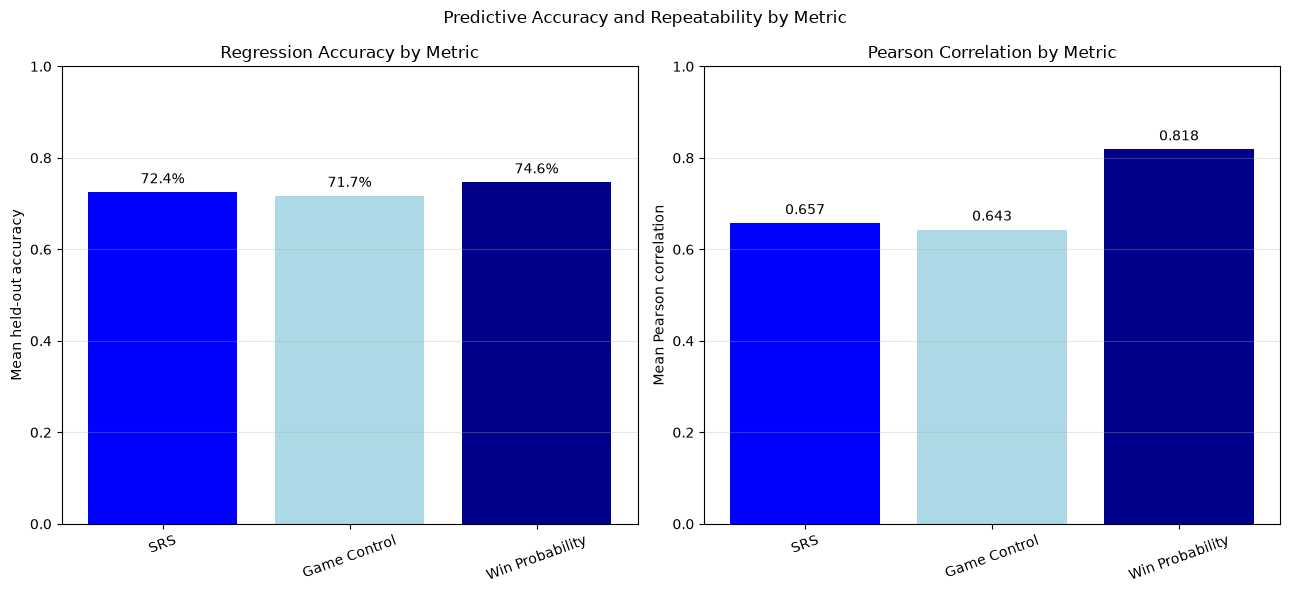

In [40]:
# metric viz
metric_order = ['SRS', 'Game Control', 'Win Probability']
metric_colors = ['blue', 'lightblue', 'darkblue']

accuracy_by_metric = (
    prediction_results.groupby('metric')['accuracy']
    .mean()
    .reindex(metric_order)
)
pearson_by_metric = (
    repeatability_results.groupby('metric')['pearson_correlation']
    .mean()
    .reindex(metric_order)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

accuracy_bars = axes[0].bar(
    accuracy_by_metric.index,
    accuracy_by_metric.values,
    color=metric_colors
)
axes[0].set_title('Regression Accuracy by Metric')
axes[0].set_ylabel('Mean held-out accuracy')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)
for bar, value in zip(accuracy_bars, accuracy_by_metric.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f'{value:.1%}',
        ha='center'
    )

pearson_bars = axes[1].bar(
    pearson_by_metric.index,
    pearson_by_metric.values,
    color=metric_colors
)
axes[1].set_title('Pearson Correlation by Metric')
axes[1].set_ylabel('Mean Pearson correlation')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', alpha=0.3)
for bar, value in zip(pearson_bars, pearson_by_metric.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f'{value:.3f}',
        ha='center'
    )

fig.suptitle('Predictive Accuracy and Repeatability by Metric')
fig.tight_layout()
plt.show()
